# Wczytanie i wstępna eksploracja danych

Celem projektu jest analiza zróżnicowania cen hotelowych na podstawie zmiennej ADR (Average Daily Rate) oraz identyfikacja czynników wpływających na poziom cen noclegów.

## Opis danych

W projekcie wkorzystano zbiór danych dotyczący rezerwacji hotelowych udostępniony przez Antonio, Almeidę i Nunesa (2019) w ramach projektu TidyTuesday.<br>

Notebook zawiera:
- charakterystykę oraz przygotowanie danych do analizy,
- analizę jakości danych, w tym identyfikację duplikatów i braków danych,
- analizę rozkładu cen hotelowych (ADR),
- analizę czynników wpływających na poziom ADR, takich jak rodzaj hotelu, typ pokoju, liczba gości, sezonowość oraz segment rynku,
- wizualizację, przetestowanie i interpretację najważniejszych zależności występujących w danych,
- prosty algorytm wskazujący w jakim stopniu dana cecha wpływa na ADR,
- podsumowanie najważniejszych wniosków z przeprowadzonej analizy.









In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (mannwhitneyu, kruskal, spearmanr, normaltest)
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeRegressor, plot_tree)
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error,r2_score)
from sklearn.model_selection import GridSearchCV

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

In [2]:
pd.set_option('display.max_columns', None)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.shape

(119390, 32)

In [4]:
df.reservation_status.unique().tolist()

['Check-Out', 'Canceled', 'No-Show']

W danych nie występuje kolumna zawierająca unikalny identyfikator rezerwacji. Na podstawie opisów zmiennych reservation_status oraz reservation_status_date można jednak wnioskować, że każdy wiersz reprezentuje końcowy status danej rezerwacji. Potwierdzają to wartości występujące w kolumnie reservation_status, obejmujące wyłącznie statusy zakończone: anulowanie rezerwacji (Canceled), zrealizowany pobyt (Check-Out) oraz niepojawienie się gościa (No-Show). W zbiorze nie występują statusy odpowiadające aktywnym lub trwającym pobytom.

# Analiza duplikatów

In [5]:
df.duplicated().sum()

np.int64(31994)

W tych danych występuje blisko 32 tysiące rekordów o identycznych wartościach we wszystkich kolumnach. Jednak na podstawie przedstawionej wcześniej interpretacji danych oraz informacji zawartych w specyfikacji zbioru, każdy wiersz został uznany za odrębną rezerwację. Zrezygnowano również z usuwania tzw. semiduplikatów, ponieważ w rzeczywistych warunkach wiele rezerwacji może posiadać bardzo podobne lub nawet identyczne cechy — np. ten sam hotel, termin pobytu, kraj pochodzenia klienta czy długość pobytu. Nie stanowi to wystarczającej podstawy do uznania rekordów za błędne duplikaty.




# Braki danych i przygotowanie danych

In [6]:
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [7]:
df[["agent", "company"]].isna().mean()

,0
agent,0.136862
company,0.943069


Brak wartości w zmiennych agent oraz company może oznaczać, że rezerwacja została dokonana bez pośrednictwa agenta lub firmy.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Zmieniam typy danych dla dat. Dodaję kolumnę z pełną datą przyjazdu oraz  miesiąc przyjazdu w wartości numerycznej, niezbędny do dalszej analizy.

In [9]:
df["arrival_date"] = pd.to_datetime( df["arrival_date_year"].astype(str)+ "-" +
pd.to_datetime(df['arrival_date_month'],format='%B').dt.month.astype(str).str.zfill(2) + "-" +
df["arrival_date_day_of_month"].astype(str))

df["arrival_date_month_num"] = pd.to_datetime(df['arrival_date_month'],format='%B').dt.month.astype(str).str.zfill(2).astype(int)

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

Zliczam całkowitą długość pobytu, dodaję kolumnę mapującą.



In [10]:
df["total_nights"] = (df["stays_in_week_nights"] + df["stays_in_weekend_nights"])
df["stay_segment"] = df["total_nights"].apply(
    lambda x:
        "One-night stay" if x == 1
        else "Short stay" if x <= 4
        else "Weekly stay" if x <= 7
        else "Up to 2 weeks" if x <= 14
        else "Up to 3 weeks" if x <= 21
        else "Extended stay"
)

In [11]:
df.children.unique()

array([ 0.,  1.,  2., 10.,  3., nan])

Weryfikuję, czy mogę zamienić Nan na 0, aby później zmienić typ na Int dla Children.


In [12]:
df[["children", "babies"]][df["children"].isna()]

,children,babies
40600,NaN,0
40667,NaN,0
40679,NaN,0
41160,NaN,0


In [13]:
df["children"] = df["children"].fillna(0).astype("int64")

In [14]:
df["total_guests"] = (df["adults"] + df["children"] + df["babies"])

# Czyszczenie i analiza zmiennej ADR

In [15]:
df['adr'].describe()

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


In [16]:
df[df['adr'] <= 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,arrival_date_month_num,total_nights,stay_segment,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,7,0,Short stay,2
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,7,0,Short stay,2
125,Resort Hotel,0,32,2015,July,27,4,0,1,4,0,0,FB,PRT,Complementary,Direct,0,0,0,H,H,2,No Deposit,NaN,NaN,0,Transient,0.0,0,1,Check-Out,2015-07-05,2015-07-04,7,1,One-night stay,4
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,H,0,No Deposit,240.0,NaN,0,Transient,0.0,0,2,Check-Out,2015-07-06,2015-07-06,7,0,Short stay,2
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,0,0,BB,PRT,Direct,Direct,0,0,0,E,H,0,No Deposit,250.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-06,2015-07-06,7,0,Short stay,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118631,City Hotel,0,78,2017,August,34,23,0,0,1,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,K,7,No Deposit,98.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2017-08-23,2017-08-23,8,0,Short stay,1
118762,City Hotel,0,1,2017,August,34,24,0,1,2,1,0,BB,PRT,Complementary,Direct,0,0,0,A,D,1,No Deposit,NaN,NaN,0,Transient,0.0,0,3,Check-Out,2017-08-25,2017-08-24,8,1,One-night stay,3
118963,City Hotel,0,1,2017,August,35,27,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2017-08-27,2017-08-27,8,0,Short stay,2
119102,City Hotel,0,518,2017,August,34,26,2,1,1,0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,229.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2017-08-29,2017-08-26,8,3,Short stay,1


Średnia cena za noc z pobytu nie może być ujemna. W zbiorze występują obserwacje z wartością ADR = 0. Analiza koncentruje się na zróżnicowaniu rzeczywistych cen noclegów, rekordy te zostały wyłączone z dalszej analizy. Wartości zerowe mogą wynikać z pobytów promocyjnych, rekompensat lub błędów w danych i nie odzwierciedlają standardowej ceny hotelowej.

In [17]:
df = df[df['adr'] > 0]

In [18]:
df['adr'].describe()

,adr
count,117430.000000
mean,103.530818
std,49.198721
min,0.260000
25%,70.530000
50%,95.000000
75%,126.000000
max,5400.000000


In [19]:
df["adr"].quantile([0.005,0.01,0.05,0.10,0.20, 0.90, 0.99, 0.999])

,adr
0.005,25.0000
0.010,29.1245
0.050,43.0000
0.100,54.5000
0.200,65.0000
0.900,165.0000
0.990,252.0000
0.999,326.5000


W celu ograniczenia wpływu obserwacji odstających usunięto wartości ADR poniżej 0.5 percentyla oraz powyżej 99.9 percentyla rozkładu. Pozwoliło to wyeliminować skrajne obserwacje przy jednoczesnym zachowaniu większości rzeczywistych cen hotelowych, w tym również droższych rezerwacji.

In [20]:
df_clean = df[(df["adr"] >= 25) & (df["adr"] <= 326.50)]

In [21]:
df_clean['adr'].describe()

,adr
count,116836.000000
mean,103.614050
std,45.749222
min,25.000000
25%,71.100000
50%,95.000000
75%,126.000000
max,326.500000


In [22]:
df_clean["adr"].quantile([0.005,0.01,0.05,0.10,0.20, 0.90, 0.99, 0.999])

,adr
0.005,29.0000
0.010,30.8000
0.050,43.4075
0.100,55.0000
0.200,65.0000
0.900,165.0000
0.990,250.0000
0.999,305.0000


Analiza percentyli zmiennej ADR pokazuje, że większość rezerwacji posiada umiarkowane ceny za noc. <br>
90% obserwacji nie przekracza wartości 165, natomiast 99.9% rezerwacji ma ADR poniżej 305. Wskazuje to na obecność niewielkiej liczby bardzo drogich pobytów oraz prawostronną asymetrię rozkładu.

Większość klientów korzysta ze standardowych ofert cenowych, jednak hotele obsługują również mniejszą grupę klientów premium wybierających znacznie droższe pobyty. <br>
Duże zróżnicowanie cen może wynikać z polityki dynamicznego ustalania cen, sezonowości oraz dostępności pokoi o różnym standardzie. <br>
Choć bardzo drogie rezerwacje występują stosunkowo rzadko, mogą one generować istotną część przychodów hoteli. <br>
Ze względu na obecność drogich rezerwacji średnia wartość ADR może być zawyżona względem typowej ceny płaconej przez większość klientów.

In [23]:
df_clean.groupby("hotel")["adr"].agg(["mean","count"])

,mean,count
hotel,,
City Hotel,107.114612,77865
Resort Hotel,96.619843,38971


In [24]:
df_clean.groupby(["hotel","reserved_room_type"])["adr"].agg(["mean", "count"])

mean  count
hotel        reserved_room_type                   
City Hotel   A                    97.826980  61503
             B                    95.550818   1051
             C                   108.795455     11
             D                   132.944077  11632
             E                   162.007160   1500
             F                   192.990652   1749
             G                   227.324439    419
Resort Hotel A                    78.359739  22715
             B                   104.666667      3
             C                   164.682404    882
             D                   104.987789   7328
             E                   115.723314   4886
             F                   136.716107   1048
             G                   167.548083   1534
             H                   182.552053    570
             L                   148.000000      5

# Statystyka opisowa ADR

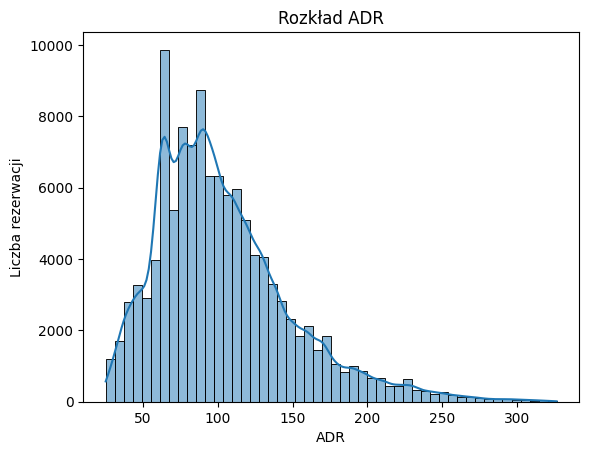

In [25]:
sns.histplot(data=df_clean, x="adr", bins = 50, kde = True)

plt.title("Rozkład ADR")
plt.xlabel("ADR")
plt.ylabel("Liczba rezerwacji")

plt.show()

Rozkład zmiennej ADR wskazuje, że większość rezerwacji cechuje się umiarkowaną ceną. Najwięcej obserwacji występuje w przedziale około 60–110 ADR, z lokalnym maksimum w okolicach 90–100. Wraz ze wzrostem wartości ADR liczba rezerwacji stopniowo maleje,<br> a bardzo drogie pobyty występują stosunkowo rzadko. Widoczny jest również wydłużony prawy ogon rozkładu, świadczący o obecności droższych rezerwacji oraz prawostronnej asymetrii danych.<br><br>

Kształt krzywej KDE może sugerować występowanie kilku segmentów cenowych w ofercie hotelowej. Dane wskazują, że hotele kierują swoją ofertę głównie do klientów zainteresowanych standardowym poziomem cenowym, przy jednoczesnym występowaniu niewielkiego segmentu klientów premium.

## Rozkład i zmienność ADR

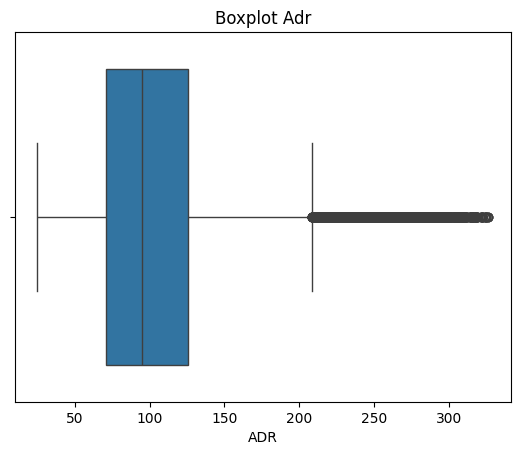

In [26]:
sns.boxplot(data=df_clean, x="adr")
plt.title("Boxplot Adr")
plt.xlabel("ADR")

plt.show()

Boxplot zmiennej ADR potwierdza prawostronną asymetrię rozkładu cen. Mediana wartości znajduje się w okolicach 95–100 ADR, natomiast środkowe 50% obserwacji mieści się w przybliżeniu w przedziale 70–125. Widoczna jest również duża liczba obserwacji odstających po prawej stronie wykresu, co wskazuje na występowanie niewielkiej grupy znacznie droższych rezerwacji.<br><br>

Brak istotnych obserwacji odstających po lewej stronie rozkładu może sugerować, że bardzo niskie ceny występują stosunkowo rzadko po wcześniejszym oczyszczeniu danych.

In [27]:
df_clean["adr"].mean()

np.float64(103.6140501215379)

Średnia wartość ADR wynosi **103,61**. Oznacza to, że przeciętna cena za dobę hotelową w analizowanym zbiorze wynosi około 104 jednostki. Należy jednak pamiętać, że średnia jest wrażliwa na wartości skrajne, dlatego sama nie daje pełnego obrazu rozkładu cen.

In [28]:
df_clean["adr"].median()

95.0

Mediana ADR wynosi **95**. Oznacza to, że połowa obserwacji charakteryzuje się ceną nie wyższą niż 95, natomiast druga połowa ceną co najmniej 95. **Mediana jest niższa od średniej**, co sugeruje występowanie prawostronnej asymetrii rozkładu – wyższe wartości ADR zawyżają średnią.

In [29]:
q1, q3 = df_clean["adr"].quantile([0.25,0.75])
print(f"q1 = {q1:.2f}")
print(f"q3 = {q3:.2f}")

q1 = 71.10
q3 = 126.00


Pierwszy kwartyl wynosi **71**, co oznacza, że 25% rezerwacji posiada ADR nie wyższy niż 71. Trzeci kwartyl wynosi **126**, co oznacza, że 75% obserwacji nie przekracza tej wartości. Innymi słowy, połowa wszystkich wartości ADR mieści się w przedziale **71–126**.

In [30]:
df_clean["adr"].std()

45.74922197083482

Odchylenie standardowe wynosi **45,75**, co oznacza, że wartości ADR przeciętnie odbiegają od średniej o około 46 jednostek. Wskazuje to na stosunkowo duże zróżnicowanie cen pomiędzy analizowanymi rezerwacjami.

In [31]:
df_clean["adr"].std()/df_clean["adr"].mean()

np.float64(0.4415349261723829)

Współczynnik zmienności wynosi **44,15%**, co świadczy o stosunkowo dużym zróżnicowaniu wartości ADR. Oznacza to, że ceny noclegów wykazują znaczną zmienność względem średniego poziomu cen.

In [32]:
q3-q1

54.900000000000006

Rozstęp międzykwartylowy (IQR) wynosi **54,9**, co oznacza, że środkowe 50%
obserwacji mieści się w przedziale o szerokości 54 jednostek. Miara ta jest odporna na wartości odstające i dobrze opisuje typową zmienność cen.

In [33]:
(q3-q1)/(q3+q1)

0.27853881278538817

Pozycyjny współczynnik zmienności wynosi **27,85%**, co wskazuje na umiarkowane zróżnicowanie centralnej części rozkładu. W porównaniu z klasycznym współczynnikiem zmienności jego niższa wartość sugeruje, że największy wpływ na całkowitą zmienność mają obserwacje o skrajnych wartościach ADR.

In [34]:
df_clean["adr"].skew()

np.float64(1.1307904262090545)

Współczynnik skośności wynosi **1,13**, co wskazuje na umiarkowaną prawostronną asymetrię rozkładu. Oznacza to, że większość obserwacji koncentruje się wokół niższych wartości ADR, natomiast niewielka liczba wysokich cen wydłuża prawy ogon rozkładu i wpływa na wzrost średniej.

In [35]:
df_clean["adr"].kurtosis()

np.float64(1.7079490510748867)

Kurtoza wynosi **1,71**, co oznacza, że rozkład jest bardziej wysmukły od rozkładu normalnego. Wskazuje to na większą koncentrację obserwacji wokół średniej oraz relatywnie częstsze występowanie wartości skrajnych niż w przypadku rozkładu normalnego.

Łącznie wszystkie miary wskazują, że zmienna ADR cechuje się dużą zmiennością oraz prawostronną asymetrią, dlatego w dalszej części analizy wykorzystywane są zarówno miary klasyczne, jak i odporne na wartości odstające.

**Test normalności** rozkładu ADR został przeprowadzony w celu sprawdzenia, czy zmienna spełnia założenie normalności, które jest wymagane przy zastosowaniu wielu klasycznych testów parametrycznych. Wynik testu pozwala zdecydować, czy w dalszej analizie można wykorzystać metody parametryczne (np. test t-Studenta lub analizę wariancji ANOVA), czy konieczne jest zastosowanie metod nieparametrycznych (np. testu Manna–Whitneya U lub Kruskala–Wallisa).<br><br>
**H0** - zmienna ADR pochodzi z rozkładu normalnego<br>
**H1** - zmienna ADR nie pochodzi z rozkładu normalnego

In [36]:
stat, p = normaltest(df_clean["adr"])
print(f"Statystyka D'Angostora = {stat:.2f}")
print(f"p-value = {p : .4f}")

Statystyka D'Angostora = 21056.78
p-value =  0.0000


In [37]:
alpha = 0.05

if p < alpha:
    print("Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej.")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej")

Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej.


Do dalszej analizy występuje konieczność zastosowania metod nieparametrycznych.

# Analiza czynników wpływających na ADR

W kolejnej części projektu przeanalizowano wpływ wybranych cech rezerwacji na wysokość ADR. Dla każdej zależności przedstawiono analizę graficzną, a następnie zweryfikowano jej istotność statystyczną odpowiednim testem.

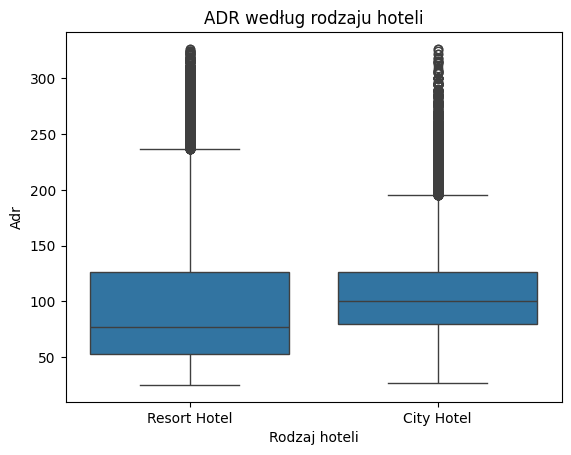

In [38]:
sns.boxplot(data=df_clean, x="hotel", y="adr")

plt.title("ADR według rodzaju hoteli")
plt.xlabel("Rodzaj hoteli")
plt.ylabel("Adr")

plt.show()

Analiza wartości ADR według rodzaju hotelu wskazuje, że City Hotel charakteryzuje się wyższą medianą cen noclegów niż Resort Hotel. Jednocześnie ceny w hotelach miejskich wydają się bardziej skoncentrowane wokół wartości centralnych, podczas gdy hotele resortowe wykazują większe zróżnicowanie cen.<br><br>

W obu typach hoteli widoczna jest duża liczba wysokich wartości odstających, co może świadczyć o występowaniu droższych ofert premium lub sezonowych wzrostów cen. Większy rozrzut cen w Resort Hotel może wynikać z bardziej zróżnicowanego charakteru pobytów wypoczynkowych oraz silniejszej sezonowości.

Ze względu na brak spełnienia założenia normalności oraz fakt, że porównywane są dwie niezależne grupy (ADR dla dwóch różnych hoteli), zastosowany zostanie nieparametryczny **test Manna–Whitneya U**. Test ten pozwala ocenić, czy rozkład badanej zmiennej różni się istotnie pomiędzy dwiema niezależnymi populacjami. <br><br>
**H0** - Rozkład ADR jest taki sam dla obu hoteli<br>
**H1** - Rozkład ADR różni sie pomiędzy hotelami.

In [39]:
cityAdr = df_clean["adr"][df_clean["hotel"]=="City Hotel"]
resortAdr = df_clean["adr"][df_clean["hotel"]=="Resort Hotel"]

stat, p = mannwhitneyu(cityAdr, resortAdr, alternative="two-sided")
print(f"Statystyka U = {stat:.2f}")
print(f"p-value = {p : .4f}")

Statystyka U = 1924963072.00
p-value =  0.0000


In [40]:
alpha = 0.05

if p < alpha:
    print("Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej")

Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej


## Typ pokoju a ADR

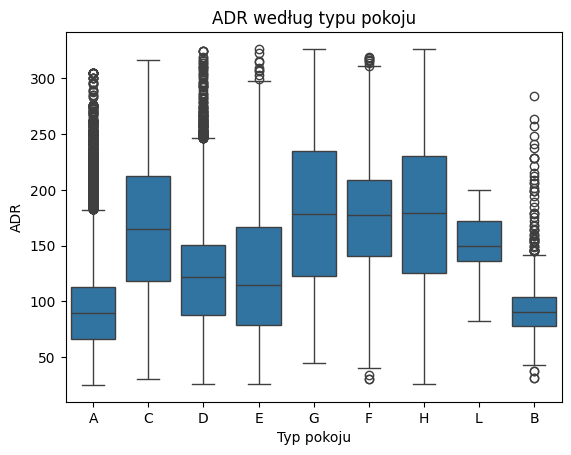

In [41]:
sns.boxplot(data= df_clean, x="reserved_room_type", y ="adr")

plt.title("ADR według typu pokoju")
plt.xlabel("Typ pokoju")
plt.ylabel("ADR")

plt.show()

Analiza ADR według typu pokoju wskazuje na wyraźne zróżnicowanie cen pomiędzy poszczególnymi kategoriami pokoi. Najwyższymi medianami ADR charakteryzują się pokoje typu G, H oraz F, co może sugerować ich wyższy standard lub większy rozmiar. Z kolei pokoje typu A i B należą do najtańszych oraz wykazują mniejsze zróżnicowanie cen.<br><br>

W wielu typach pokoi widoczne są również liczne wysokie wartości odstające, co wskazuje na występowanie droższych ofert premium lub okresowych wzrostów cen. Duży rozrzut wartości ADR w obrębie części kategorii może sugerować wpływ dodatkowych czynników, takich jak sezonowość, popyt czy długość pobytu.

Zostanie wykorzystany **test Kruskala–Wallisa**, ponieważ zmienna ADR nie spełnia założenia normalności rozkładu, a analizowane są więcej niż dwie niezależne grupy — w tym przypadku różne typy pokoi. Test Kruskala–Wallisa jest nieparametrycznym odpowiednikiem jednoczynnikowej analizy wariancji (ANOVA) i pozwala sprawdzić, czy rozkład badanej zmiennej różni się pomiędzy kilkoma niezależnymi grupami.<br><br>
**H0** - Rozkład ADR jest taki sam dla wszystkich typów pokoi.<br>
**H1** - Co najmniej jeden typ pokoju ma inny rozkład ADR.

In [42]:
groups = [group["adr"].values for _ , group in df_clean.groupby("reserved_room_type")]
stat, p = kruskal(*groups)

print(f"Statystyka H = {stat:.2f}")
print(f"p-value = {p : .4f}")

Statystyka H = 15895.96
p-value =  0.0000


In [43]:
if p < alpha:
    print("Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej")

Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej


Oznacza to, że typ pokoju należy do czynników, które powinny zostać uwzględnione podczas budowy modelu predykcyjnego.

## Sezonowość cen hotelowych

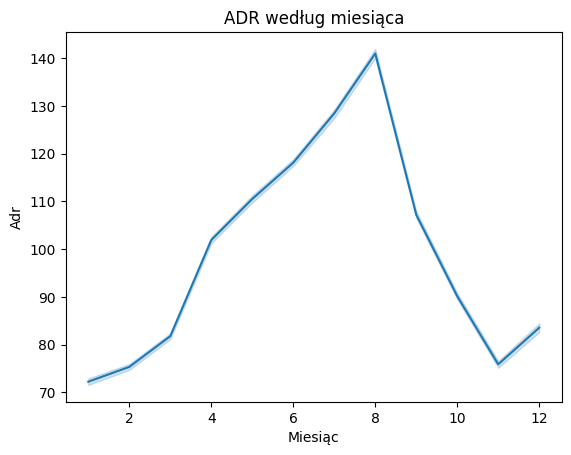

In [44]:
sns.lineplot(data=df_clean.sort_values(by="arrival_date_month_num"), x="arrival_date_month_num", y="adr")

plt.title("ADR według miesiąca")
plt.xlabel("Miesiąc")
plt.ylabel("Adr")

plt.show()

Analiza średnich wartości ADR w kolejnych miesiącach wskazuje na wyraźną sezonowość cen hotelowych. Wartości ADR stopniowo rosną od początku roku, osiągając najwyższy poziom w miesiącach wakacyjnych — szczególnie w lipcu i sierpniu. Po zakończeniu sezonu letniego widoczny jest spadek średnich cen noclegów.<br><br>

Może to sugerować silny wpływ sezonowego popytu na politykę cenową hoteli, szczególnie w okresie wakacyjnym, kiedy zainteresowanie usługami noclegowymi jest największe.<br><br>

Dane zostały zagregowane na poziomie miesięcy, bez uwzględniania podziału na poszczególne lata, ponieważ celem analizy było przedstawienie ogólnego wzorca sezonowości cen hotelowych, a nie zmian cen w czasie.

Wstępna eksploracja danych sugerowała również tendencję do niższych wartości ADR przy dłuższych pobytach, jednak zależność ta nie była na tyle wyraźna, aby uwzględnić ją w głównej części analizy.

Zostanie wykorzystany **test Kruskala–Wallisa**, ponieważ zmienna ADR nie spełnia założenia normalności rozkładu, a analiza obejmuje porównanie więcej niż dwóch niezależnych grup — w tym przypadku wartości ADR w poszczególnych miesiącach.

**H0** - Rozkład ADR jest taki sam we wszystkich miesiącach. <br>
**H1** - Przynajmniej jeden miesiąc różni się pod względem ADR

In [45]:
month_groups = [
    group["adr"].values for _, group in df_clean.sort_values("arrival_date_month_num")
    .groupby("arrival_date_month_num")
]
H, p = kruskal(*month_groups)

print(f"Statystyka H = {H:.2f}")
print(f"p-value = {p : .2f}")

Statystyka H = 27703.71
p-value =  0.00


In [46]:
if p < alpha:
    print("Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej")

Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej


In [47]:
k = df_clean["arrival_date_month_num"].nunique()
n = len (df_clean)
epsilon_squared = (H -k +1)/(n- k)

print(f"Epsilon squared = {epsilon_squared: .3f}")

Epsilon squared =  0.237


Na wykresie w pierwszej części raportu zaobserwowano wyrażne różnice wartości ADR pomiędzy miesiącami. W celu  sprawdzenia, czy obserwowane różnice są istotne statystycznie, zastosowano test Kruskala-Wallisa. Jego wynik potwierdził istotne różnice ADR pomiędzy miesiącami, jednak wielkośc efektu wynosiła **Episilon**= 0.237 co wskazuje na średni wpływ sezonowości

Różnice pomiędzy miesiącami są istotne statystycznie i mają **średnią** wielkość efektu, co oznacza, że sezonowość w zauważalnym stopniu wpływa na wartośc ADR.

Wynik ten jest zgodny z charakterystyką rynku hotelarskiego, gdzie okresy wakacyjne i urlopowe wiążą się ze zwiększonym popytem oraz możliwością stosowania wyższych cen.

## Sezonowość cen hotelowych z podziałem na rodzaj hotelu

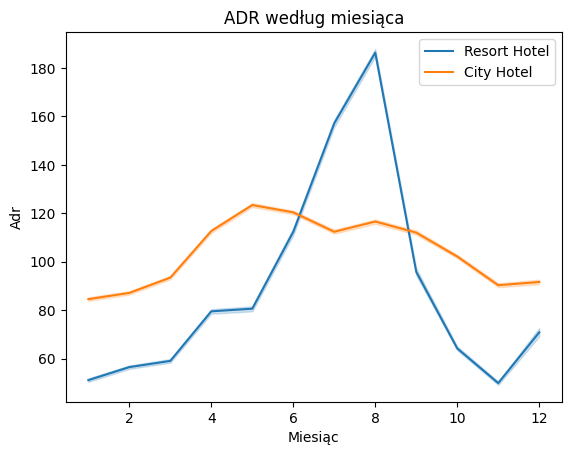

In [48]:
sns.lineplot(data=df_clean.sort_values(by="arrival_date_month_num"), x="arrival_date_month_num", y="adr", hue="hotel", estimator="mean")

plt.title("ADR według miesiąca")
plt.xlabel("Miesiąc")
plt.ylabel("Adr")
plt.legend()

plt.show()

Analiza z podziałem na rodzaj hotelu wskazuje, że sezonowość cen jest szczególnie widoczna w hotelach resortowych. W okresie wakacyjnym (lipiec–sierpień) ADR osiąga tam najwyższe wartości, podczas gdy poza sezonem ceny znacząco spadają. W przypadku hoteli miejskich zmienność cen jest znacznie mniejsza, a poziom ADR pozostaje bardziej stabilny w ciągu roku. Może to wynikać z odmiennego charakteru obu typów obiektów oraz większej zależności hoteli resortowych od ruchu turystycznego.

## Liczba gości a ADR

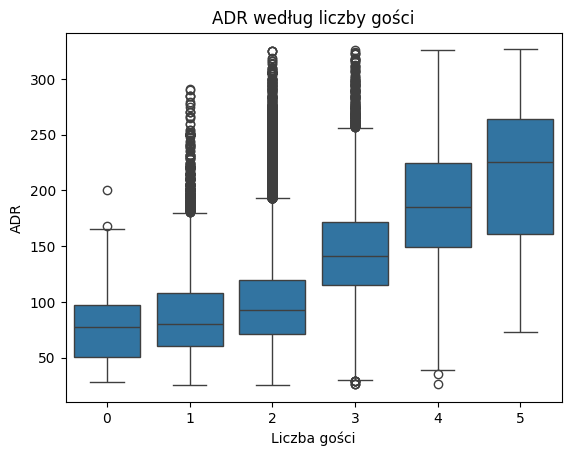

In [49]:
sns.boxplot(data=df_clean[df_clean["total_guests"]<=5], x="total_guests",y="adr")

plt.xlabel("Liczba gości")
plt.ylabel("ADR")
plt.title("ADR według liczby gości")

plt.show()

Analiza ADR według liczby gości wskazuje na wyraźną zależność pomiędzy wielkością rezerwacji a ceną noclegu. Wraz ze wzrostem liczby osób uczestniczących w pobycie rośnie zarówno mediana wartości ADR, jak i ogólny poziom cen.<br><br>

Najwyższe wartości ADR obserwowane są dla rezerwacji obejmujących 4–5 gości, co może wynikać z konieczności rezerwacji większych pokoi rodzinnych lub apartamentów o wyższym standardzie. Jednocześnie większe grupy charakteryzują się większym zróżnicowaniem cen, co sugeruje bardziej zróżnicowaną ofertę dostępnych pokoi.<br><br>
W danych występują również pojedyncze rezerwacje z liczbą gości równą 0. Mogą one wynikać z błędów w procesie gromadzenia danych lub niekompletnie zapisanych informacji o rezerwacji.

Do zbadania zależności pomiędzy ADR a liczbą gości zostanie wykorzystany **test Spearmana**. Metoda ta została wybrana ze względu na brak założenia o normalności rozkładu danych oraz możliwość wykrywania monotonicznych zależności pomiędzy zmiennymi. Test Spearmana pozwala określić, czy wraz ze wzrostem jednej zmiennej występuje systematyczna zmiana drugiej zmiennej, niezależnie od tego, czy zależność ma charakter liniowy.<br><br>
**H0** - Nie istnieje monotoniczna zależnośc pomiędzy ADR i liczbą gości.<br>
**H1** - Istnieje monotoniczna zależnośc pomiędzy ADR i liczbą gości.

In [50]:
rho, p = spearmanr(df_clean["adr"], df_clean["total_guests"])
print(f"Rho = {rho: .3f}")
print(f"p-value = {p : .4f}")

Rho =  0.354
p-value =  0.0000


In [51]:
if p < alpha:
    print("Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej")
else:
    print("Nie ma podstaw do odrzucenia hipotezy zerowej")

Na poziomie istotności alpha = 0.05 istnieją podstawy do odrzucenia hipotezy zerowej


Może to sugerować, że wielkość rezerwacji jest jednym z czynników wpływających na politykę cenową hoteli.

## Kanał sprzedaży a ADR

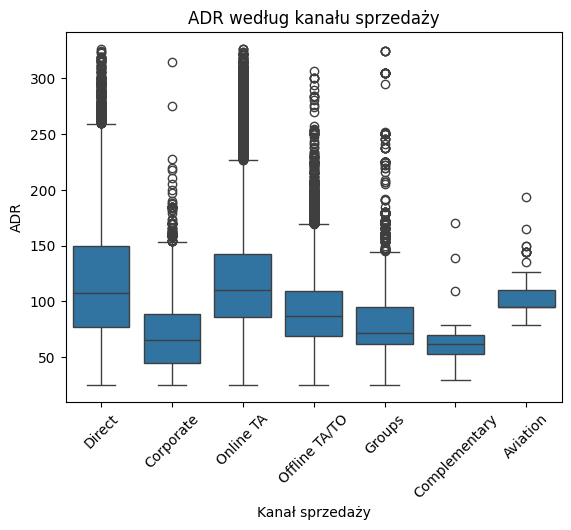

In [52]:
sns.boxplot(data=df_clean, x="market_segment", y="adr")

plt.xticks(rotation=45)
plt.title("ADR według kanału sprzedaży")
plt.xlabel("Kanał sprzedaży")
plt.ylabel("ADR")

plt.show()

Analiza wskazuje, że poziom ADR różni się w zależności od segmentu rynku. Najwyższe mediany cen obserwowane są dla rezerwacji realizowanych bezpośrednio oraz przez internetowe biura podróży (Online TA). Z kolei niższe wartości ADR występują częściej w segmencie korporacyjnym (Corporate) oraz w rezerwacjach oznaczonych jako Complementary. Może to sugerować, że sposób pozyskania klienta jest jednym z czynników związanych ze zróżnicowaniem cen noclegów.

Przeprowadzona analiza eksploracyjna wykazała, że wysokość ADR zależy od wielu czynników związanych zarówno z charakterystyką rezerwacji, jak i sezonowością oraz typem hotelu. Wykorzystane testy statystyczne potwierdziły istotność większości zaobserwowanych zależności. Analiza pojedynczych zmiennych nie pozwala jednak określić ich łącznego wpływu na wysokość ADR. W kolejnym etapie zastosowano model regresyjny oparty na drzewie decyzyjnym, którego zadaniem jest jednoczesne uwzględnienie wszystkich analizowanych cech oraz określenie ich względnego znaczenia dla przewidywania wartości ADR.

# Identyfikacja najważniejszych czynników wpływających na ADR

Celem modelowania było zidentyfikowanie cech rezerwacji,któe w największym stopniu wpływają na wysokośc średniej ceny dobowej (ADR). Oprócz uzyskania modelu predykcyjnego celem było rownież zrozumienie znaczenia poszczegółnych zmiennych oraz ich wpływu na przewidywaną wartośc ADR.

Zmienną objaśnianą w analizie jest średnia cena dobowa (ADR), która ma charakter ilościowy ciągły. W analizie eksploracyjnej stwierdzono prawostronną skośność rozkładu oraz brak normalności. Dodatkowo zbiór danych zawiera liczne zmienne kategoryczne oraz istnieje możliwość występowania nieliniowych zależności pomiędzy cechami rezerwacji a wysokością ADR. Z tego względu zdecydowano się na zastosowanie modelu Decision Tree Regressor, który nie wymaga spełnienia założeń regresji liniowej, dobrze radzi sobie z nieliniowością oraz umożliwia interpretację wpływu poszczególnych zmiennych za pomocą struktury drzewa i miar ważności cech. Dodatkową zaletą wybranego modelu jest możliwość interpretacji ważności poszczególnych cech, co pozwala odpowiedzieć nie tylko na pytanie "jak dobrze model przewiduje ADR", ale również "które zmienne mają największy wpływ na jego wartość".

## Przygotowanie danych do modelowania

Przed rozpoczęciem modelowania wybrano zmienne, które mogły potencjalnie wpływać na wysokość **średniej ceny dobowej (ADR)**,<br> a jednocześnie były dostępne na etapie dokonywania rezerwacji. Dzięki temu model opiera się wyłącznie na informacjach, które mogłyby zostać wykorzystane do prognozowania ceny w praktyce.<br>

Z analizy wykluczono zmienne zawierające informacje niedostępne w momencie rezerwacji, takie jak **reservation_status**, **reservation_status_date**, **assigned_room_type** oraz **is_canceled**, ponieważ ich wykorzystanie prowadziłoby do zjawiska **data leakage**, czyli nieuprawnionego wykorzystania informacji z przyszłości.<br>

Pominięto również zmienne o bardzo dużej liczbie kategorii (**country, agent, company**), które zwiększałyby złożoność modelu i utrudniały interpretację wyników. Dodatkowo zrezygnowano z cech opisujących tę samą informację w kilku kolumnach. Liczbę dorosłych, dzieci i niemowląt zastąpiono zmienną **total_guests**, natomiast liczbę noclegów w tygodniu i weekendów zastąpiono zmienną **total_nights**. Pozwoliło to ograniczyć redundancję danych oraz uprościć interpretację modelu.

In [53]:
features = [
    "hotel",
    "lead_time",
    "arrival_date_month_num",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "meal",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "booking_changes",
    "deposit_type",
    "days_in_waiting_list",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "stay_segment",
    "total_guests",
    "total_nights"
]

X = df_clean[features]
y = df_clean["adr"]

Sprawdzam, czy w danych nie ma żadnych braków oraz jakie typy danych występują, aby następnie wydzielić cechy numeryczne i kategorialne.

In [54]:
quality = pd.DataFrame({
    "dtype": X.dtypes,
    "missing": X.isna().sum(),
    "missing_%": (X.isna().mean()*100).round(2),
    "unique": X.nunique()
})

quality.sort_values("missing_%", ascending=False)

,dtype,missing,missing_%,unique
hotel,object,0,0.0,2
lead_time,int64,0,0.0,478
arrival_date_month_num,int64,0,0.0,12
arrival_date_week_number,int64,0,0.0,53
arrival_date_day_of_month,int64,0,0.0,31
meal,object,0,0.0,5
market_segment,object,0,0.0,7
distribution_channel,object,0,0.0,5
is_repeated_guest,int64,0,0.0,2
previous_cancellations,int64,0,0.0,15


Analiza jakości danych wykazała brak brakujących wartości w zmiennych wykorzystanych do modelowania. Dodatkowo zweryfikowano typ danych każdej cechy oraz liczbę unikalnych wartości. Pozwoliło to potwierdzić poprawność przygotowanego zbioru przed rozpoczęciem procesu uczenia modelu. Dzięki temu można było przejść do budowy modelu bez konieczności dodatkowego uzupełniania braków danych lub transformacji typów zmiennych.

Dane zostały podzielone na zbiór treningowy (80%) oraz testowy (20%). Model był uczony wyłącznie na zbiorze treningowym, natomiast zbiór testowy został wykorzystany do oceny jakości predykcji na wcześniej niewidzianych obserwacjach.

In [55]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [56]:
numeric_features = X_train.select_dtypes(exclude="object").columns
print(numeric_features)

Index(['lead_time', 'arrival_date_month_num', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'total_nights'],
      dtype='object')


In [57]:
categorical_features = X_train.select_dtypes(include="object").columns
print(categorical_features)

Index(['hotel', 'meal', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'deposit_type', 'customer_type', 'stay_segment'],
      dtype='object')


Zmienne kategoryczne zostały zakodowane metodą **One-Hot Encoding**, dzięki czemu każda kategoria została przedstawiona jako oddzielna zmienna binarna. Pozwoliło to przygotować dane w postaci numerycznej wymaganej przez algorytm Decision Tree Regressor.

In [58]:
# Zmienne kategoryczne zakodowane
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=False)

# Zmienne numeryczne
X_train_num = X_train[numeric_features]

# Połączenie
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)

In [59]:
# Zmienne kategoryczne zakodowane
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=False)

# Zmienne numeryczne
X_test_num = X_test[numeric_features]

# Połączenie
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)
X_test_final = X_test_final.reindex(
    columns=X_train_final.columns,
    fill_value=0
)

## Budowa modelu

Ze względu na brak normalności rozkładu ADR oraz możliwość występowania zależności nieliniowych zrezygnowano z zastosowania regresji liniowej jako modelu końcowego. Zdecydowano się na wykorzystanie **Decision Tree Regressor**, który umożliwia modelowanie nieliniowych zależności oraz pozwala na interpretację wpływu poszczególnych cech na przewidywaną wartość ADR.

In [60]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_final, y_train)

DecisionTreeRegressor(random_state=42)

Model został wytrenowany na zbiorze treningowym, natomiast jego skuteczność oceniono na zbiorze testowym, który nie uczestniczył w procesie uczenia.

In [61]:
# Predykcja
y_pred_test_model = model.predict(X_test_final)
y_pred_train_model = model.predict(X_train_final)

W celu ocenienia skuteczności powyższego modelu oraz weryfikacji czy nie zachodzi overfitting korzystam z biblioteki **metrics**

In [62]:
# TRAIN⅞
mae_train_model = mean_absolute_error(y_train, y_pred_train_model)
rmse_train_model = root_mean_squared_error(y_train, y_pred_train_model)
r2_train_model = r2_score(y_train, y_pred_train_model)

# TEST
mae_test_model = mean_absolute_error(y_test, y_pred_test_model)
rmse_test_model = root_mean_squared_error(y_test, y_pred_test_model)
r2_test_model = r2_score(y_test, y_pred_test_model)

print("===== MODEL TRAIN =====")
print(f"MAE : {mae_train_model:.2f}")
print(f"RMSE: {rmse_train_model:.2f}")
print(f"R²  : {r2_train_model:.4f}")

print("\n===== MODEL TEST =====")
print(f"MAE : {mae_test_model:.2f}")
print(f"RMSE: {rmse_test_model:.2f}")
print(f"R²  : {r2_test_model:.4f}")

===== MODEL TRAIN =====
MAE : 0.18
RMSE: 1.66
R²  : 0.9987

===== MODEL TEST =====
MAE : 10.52
RMSE: 20.89
R²  : 0.7909


Model w konfiguracji domyślnej na zbiorze testowym osiągnął średni błąd bezwzględny (MAE) równy **10,52**, pierwiastek z błędu średniokwadratowego (RMSE) równy **20,89** oraz współczynnik determinacji **R² = 0,7909**. Oznacza to, że model wyjaśnia około **79**% zmienności wartości ADR, pozostawiając około **21% niewyjaśnionej zmienności.**

Analiza wyników uzyskanych dla zbioru treningowego **(R² = 0,9987)** i testowego **(R² = 0,7909)** wskazuje jednak na wyraźną różnicę w skuteczności modelu. Niemal idealne dopasowanie do danych treningowych przy zauważalnie niższej jakości predykcji na zbiorze testowym sugeruje występowanie **przeuczenia (overfittingu).** W związku z tym w kolejnym etapie przeprowadzono strojenie hiperparametrów z wykorzystaniem **GridSearchCV** w celu poprawy zdolności modelu do uogólniania na nowych danych.

In [63]:
param_grid = {
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [10, 12, 15, 18, 20],
    "min_samples_leaf": [6, 7, 8, 9, 10]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_final, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 7, 'min_samples_split': 20}
0.8260802204905403


Proces strojenia hiperparametrów miał charakter iteracyjny. Po analizie wyników pierwszego przeszukiwania doprecyzowano zakres badanych wartości parametrów, co pozwoliło wyznaczyć konfigurację zapewniającą najlepszy kompromis pomiędzy jakością dopasowania a zdolnością modelu do uogólniania.

In [64]:
best_model = grid.best_estimator_

In [65]:
# Predykcja
y_pred_train_best = best_model.predict(X_train_final)
y_pred_test_best = best_model.predict(X_test_final)

Do weryfikacji poziomu ulepszenia modelu zostały wyliczone takie same miary z biblioteki **metrics**

In [66]:
# TRAIN⅞
mae_train_best = mean_absolute_error(y_train, y_pred_train_best)
rmse_train_best = root_mean_squared_error(y_train, y_pred_train_best)
r2_train_best = r2_score(y_train, y_pred_train_best)

# TEST
mae_test_best = mean_absolute_error(y_test, y_pred_test_best)
rmse_test_best = root_mean_squared_error(y_test, y_pred_test_best)
r2_test_best = r2_score(y_test, y_pred_test_best)

print("===== BEST MODEL TRAIN =====")
print(f"MAE : {mae_train_best:.2f}")
print(f"RMSE: {rmse_train_best:.2f}")
print(f"R²  : {r2_train_best:.4f}")

print("\n===== BEST MODEL TEST =====")
print(f"MAE : {mae_test_best:.2f}")
print(f"RMSE: {rmse_test_best:.2f}")
print(f"R²  : {r2_test_best:.4f}")

===== BEST MODEL TRAIN =====
MAE : 8.37
RMSE: 14.30
R²  : 0.9024

===== BEST MODEL TEST =====
MAE : 10.98
RMSE: 18.71
R²  : 0.8323


Po przeprowadzeniu iteracyjnego strojenia hiperparametrów z wykorzystaniem **GridSearchCV** uzyskano model o lepszej zdolności do uogólniania. Na zbiorze testowym model osiągnął średni błąd bezwzględny (MAE) równy **10,98**, pierwiastek z błędu średniokwadratowego (RMSE) równy **18,71** oraz współczynnik determinacji **R² = 0,8323**. Oznacza to, że model wyjaśnia około **83% zmienności** wartości ADR, pozostawiając około **17% niewyjaśnionej zmienności**.<br>

W porównaniu z modelem w konfiguracji domyślnej uzyskano niewielką poprawę jakości predykcji na zbiorze testowym (wzrost R² z **0,7909** do **0,8323** oraz spadek RMSE z **20,89** do **18,71**). Jednocześnie zmniejszyła się różnica pomiędzy wynikami osiąganymi na zbiorze treningowym i testowym, co wskazuje na **ograniczenie zjawiska przeuczenia (overfittingu)** oraz poprawę zdolności modelu do uogólniania zależności występujących w nowych danych, dlatego model po optymalizacji został ostatecznie przyjęty jako model końcowy.<br>

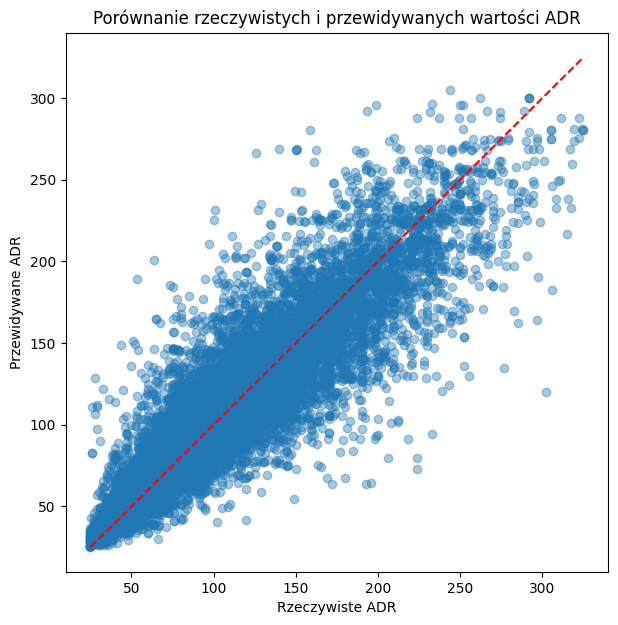

In [67]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_test_best, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")

plt.xlabel("Rzeczywiste ADR")
plt.ylabel("Przewidywane ADR")
plt.title("Porównanie rzeczywistych i przewidywanych wartości ADR")
plt.show()

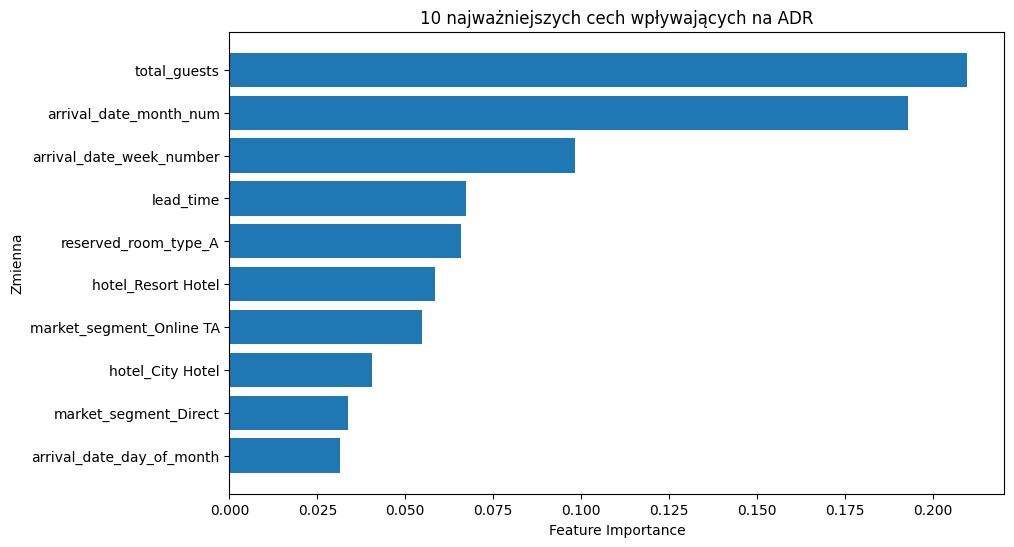

In [68]:
importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance.head(10)["Feature"][::-1],
    importance.head(10)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Zmienna")
plt.title("10 najważniejszych cech wpływających na ADR")

plt.show()

Największy wpływ na przewidywaną wartość ADR miała **liczba gości**, co wskazuje, że cena noclegu silnie zależy od wielkości rezerwacji. Istotne znaczenie miały również zmienne opisujące **termin przyjazdu** (miesiąc i tydzień roku), potwierdzając wcześniej zaobserwowaną sezonowość cen. Wysoką ważność uzyskał także czas **wyprzedzenia rezerwacji** (lead_time), co sugeruje, że moment dokonania rezerwacji wpływa na stosowaną politykę cenową hoteli. Znaczenie **typu zarezerwowanego pokoju** jest zgodne z intuicją – różne standardy pokoi wiążą się z odmiennym poziomem cen.
Wyniki są zgodne z wcześniejszą analizą eksploracyjną, która wykazała istotne zróżnicowanie cen w zależności od tych czynników. Potwierdza to, że model wykorzystuje zależności zaobserwowane już na etapie EDA.

# PODSUMOWANIE

Celem projektu była analiza czynników wpływających na wysokość **średniej ceny dobowej rezerwacji hotelowych (ADR – Average Daily Rate)** oraz budowa modelu umożliwiającego identyfikację najważniejszych determinant tej zmiennej. Analizę przeprowadzono na danych dotyczących rezerwacji w hotelach typu **City Hotel** oraz **Resort Hotel**.

Na etapie przygotowania danych przeprowadzono analizę jakości zbioru, obejmującą identyfikację duplikatów, braków danych oraz obserwacji odstających. Dla zmiennej ADR usunięto wartości skrajne, które mogły zaburzać analizę typowych cen hotelowych. Następnie wykonano eksploracyjną analizę danych oraz przeprowadzono testy statystyczne pozwalające zweryfikować zaobserwowane zależności.

Analiza wykazała, że rozkład zmiennej ADR charakteryzuje się wyraźną **prawostronną asymetrią**, co oznacza, że większość rezerwacji dotyczy umiarkowanych cen noclegów, natomiast jedynie niewielka część obserwacji obejmuje bardzo wysokie wartości. Potwierdzono również występowanie sezonowości cen hotelowych oraz zróżnicowania wartości ADR pomiędzy wybranymi grupami rezerwacji.

W celu identyfikacji najważniejszych czynników wpływających na wysokość ADR zbudowano model **Decision Tree Regressor**. Po optymalizacji hiperparametrów z wykorzystaniem **GridSearchCV** model osiągnął na zbiorze testowym współczynnik determinacji<br> **R² = 0,8323**, co oznacza, że wyjaśnia około **83% zmienności wartości ADR.** Strojenie hiperparametrów pozwoliło ograniczyć zjawisko przeuczenia oraz poprawić zdolność modelu do uogólniania wyników.

Analiza ważności cech wykazała, że największy wpływ na wysokość ADR mają **liczba gości (total_guests), termin pobytu (miesiąc oraz tydzień roku), czas wyprzedzenia rezerwacji (lead_time), typ zarezerwowanego pokoju oraz typ hotelu.** Istotne znaczenie miał również **segment rynku**, co wskazuje, że sposób dokonania rezerwacji również wpływa na poziom stosowanych cen. Wyniki modelu są spójne z wcześniejszymi obserwacjami dotyczącymi sezonowości cen oraz zróżnicowania wartości ADR pomiędzy analizowanymi grupami.

Przeprowadzona analiza pokazuje, że wysokość średniej ceny dobowej nie jest determinowana przez pojedynczy czynnik, lecz przez współwystępowanie cech opisujących termin pobytu, charakter rezerwacji oraz właściwości hotelu. Połączenie eksploracyjnej analizy danych, metod statystycznych oraz modelowania predykcyjnego pozwoliło nie tylko lepiej zrozumieć mechanizmy kształtowania cen hotelowych, ale również wskazać cechy, które mają największe znaczenie przy przewidywaniu wartości ADR.